# **Superstore Sales Forecasting dengan SARIMAX di Microsoft Fabrics**


## Prasyarat

* [Menambahkan lakehouse](https://aka.ms/fabric/addlakehouse) ke notebook ini. <br> Kita akan mengunduh data dari blob publik, kemudian menyimpan data tersebut ke dalam lakehouse.

## Pendahuluan

**Forecasting** adalah proses memprediksi kondisi di masa depan berdasarkan data dan pola yang terjadi di masa lalu. Dengan adanya *forecasting*, tim sales dan manajemen dapat mengambil keputusan secara terencana dan proaktif, bukan sekadar bereaksi terhadap keadaan yang sedang terjadi. Dalam konteks **Sales Forecasting**, kemampuan untuk memperkirakan angka penjualan di masa mendatang sangat krusial bagi kesehatan bisnis, di antaranya untuk:
* **Perencanaan Inventaris:** Memastikan stok barang selalu tersedia sesuai permintaan tanpa harus menumpuk modal di gudang.
* **Target & Alokasi Sumber Daya:** Membantu manajemen menetapkan target penjualan yang realistis dan mengalokasikan tenaga sales ke wilayah atau kategori produk yang potensial.
* **Manajemen Arus Kas:** Memprediksi pendapatan di masa depan sehingga perusahaan dapat mengatur anggaran operasional dan investasi dengan lebih aman.

### Tahapan Pengerjaan

Notebook ini merangkum proses pembangunan model **Sales Forecasting** menggunakan data penjualan **Superstore** melalui lima tahapan utama:

1. **Memuat Data** Mengambil data penjualan historis dari *lakehouse* ke dalam notebook sebagai bahan baku utama untuk seluruh analisis.

2. **Eksplorasi Data (EDA)** Mempelajari karakteristik data, seperti tren kenaikan penjualan atau pola musim tertentu, serta membersihkan data agar siap diolah oleh model.

3. **Pelatihan Model & Pelacakan Eksperimen** Menggunakan model statistik **SARIMAX** yang andal dalam menangkap pola musiman. Proses ini dipantau secara otomatis menggunakan **MLflow** untuk mencatat setiap hasil eksperimen dengan rapi.

4. **Penyimpanan Model & Prediksi** Memilih model terbaik untuk menghasilkan angka prediksi di masa mendatang, kemudian menyimpannya agar hasil tersebut terintegrasi dengan proses analitik lainnya.

5. **Visualisasi Hasil Akhir** Menampilkan perbandingan antara data penjualan asli dan hasil prediksi melalui grafik di **Power BI**. Hal ini memudahkan pemangku kepentingan untuk melihat tingkat akurasi model secara langsung.


## Mengimpor Library dan Mendefinisikan Parameter Konfigurasi

Langkah awal yang krusial adalah mempersiapkan seluruh "alat" (library) dan parameter konfigurasi yang diperlukan. 

Meskipun mendefinisikan parameter konfigurasi di awal bersifat opsional, praktik ini sangat direkomendasikan karena:
* **Fleksibilitas:** Notebook dapat dengan mudah diadaptasi untuk dataset atau periode waktu yang berbeda tanpa mengubah logika kode di bagian bawah.
* **Kerapian:** Seluruh pengaturan penting terkumpul di satu tempat, memudahkan proses pemantauan dan perubahan cepat.
* **Efisiensi:** Mempercepat proses pemecahan masalah (*debugging*) karena variabel kunci sudah terpusat.

Langkah ini memastikan bahwa alur pengerjaan kita tetap teratur dan siap untuk dikembangkan lebih lanjut.

In [2]:
# Library standar untuk manajemen sistem dan durasi proses
import os
import time
import warnings
import itertools

# Library utama untuk pengolahan data tabel dan komputasi angka
import requests
import numpy as np
import pandas as pd

# Library untuk pembuatan grafik dan visualisasi data
import matplotlib
import matplotlib.pyplot as plt

# Library statistik untuk membangun model peramalan (forecasting)
import statsmodels.api as sm

# Library untuk mendokumentasikan setiap eksperimen model secara otomatis
import mlflow

# Metrik evaluasi untuk mengukur tingkat akurasi hasil prediksi
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error
)

# Menonaktifkan pesan peringatan agar tampilan notebook lebih rapi dan fokus
warnings.filterwarnings("ignore")

# Mengatur standar visualisasi agar grafik konsisten dan mudah dibaca
plt.style.use("fivethirtyeight")
matplotlib.rcParams.update({
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "text.color": "k"
})

# --- Parameter Kendali Data ---
IS_CUSTOM_DATA = False  # Ubah ke True jika ingin menggunakan dataset eksternal
IS_SAMPLE = False       # Ubah ke True jika ingin memproses sebagian data untuk pengujian cepat
SAMPLE_ROWS = 5000      # Jumlah baris data yang digunakan jika mode 'Sample' aktif

# --- Lokasi Penyimpanan Data di Lakehouse ---
DATA_ROOT = "/lakehouse/default"
DATA_FOLDER = "Files/salesforecast"  # Folder tujuan penyimpanan data
DATA_FILE = "Superstore.xlsx"        # Nama file dataset yang akan diolah

# --- Identitas Eksperimen ---
EXPERIMENT_NAME = "aisample-superstore-forecast-2"  # Nama identitas proyek pada MLflow

# --- Parameter Waktu Peramalan ---
# Menentukan periode pengujian model dan periode prediksi masa depan
VALIDATION_MONTHS = 12  # 12 bulan terakhir digunakan sebagai data uji untuk memvalidasi akurasi model
FORECAST_MONTHS   = 12  # Jumlah periode bulan yang akan diprediksi oleh model ke depannya

ModuleNotFoundError: No module named 'pkg_resources'

## Mengunduh Dataset dan Mengunggahnya ke Lakehouse

Tahap ini bertujuan untuk menarik dataset dari sumber publik dan menyimpannya secara permanen ke dalam **Fabric Lakehouse**. Dengan menyimpan data di Lakehouse, kita memastikan bahwa data tersedia secara terpusat dan siap untuk diolah kapan saja.

> **Penting:** Pastikan Anda telah [menambahkan lakehouse](https://aka.ms/fabric/addlakehouse) ke dalam notebook ini sebelum menjalankan kode di bawah. Jika lakehouse belum terhubung, proses penyimpanan data akan menghasilkan error.

Proses ini dilakukan secara otomatis melalui kode berikut untuk menjamin konsistensi data yang digunakan dalam analisis.

In [ ]:
if not IS_CUSTOM_DATA:
    # Mengunduh dataset demo jika pengguna tidak menggunakan data sendiri
    remote_url = "https://synapseaisolutionsa.z13.web.core.windows.net/data/Forecast_Superstore_Sales"
    file_list = ["Superstore.xlsx"]
    download_path = "/lakehouse/default/Files/salesforecast/raw"

    # Memastikan koneksi ke Lakehouse sudah terpasang
    if not os.path.exists("/lakehouse/default"):
        raise FileNotFoundError(
            "Lakehouse default tidak ditemukan. Harap tambahkan lakehouse ke notebook dan mulai ulang sesi."
        )

    # Membuat folder tujuan jika belum tersedia
    os.makedirs(download_path, exist_ok=True)

    # Proses pengunduhan file dari server ke folder Lakehouse
    for fname in file_list:
        if not os.path.exists(f"{download_path}/{fname}"):
            # Mengambil file dari URL publik dengan batas waktu tunggu 30 detik
            r = requests.get(f"{remote_url}/{fname}", timeout=30)
            with open(f"{download_path}/{fname}", "wb") as f:
                f.write(r.content)

    print("File data demo berhasil diunduh ke dalam lakehouse.")

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 4, Finished, Available, Finished, False)

File data demo berhasil diunduh ke dalam lakehouse.


## Menyiapkan Pelacakan Eksperimen MLflow

Microsoft Fabric memiliki fitur **MLflow autologging** yang sangat memudahkan kita. Fitur ini secara otomatis merekam parameter input dan metrik hasil dari model *machine learning* selama proses pelatihan. 

Semua informasi ini tersimpan rapi di dalam *workspace*, sehingga kita bisa meninjau kembali atau membandingkan berbagai hasil eksperimen dengan mudah melalui API MLflow atau menu eksperimen di *workspace*. 

* **Pelajari Lebih Lanjut:** Untuk informasi detail mengenai fitur ini, Anda dapat mengunjungi dokumentasi [Autologging di Microsoft Fabric](https://aka.ms/fabric-autologging).
* **Catatan:** Jika Anda perlu menonaktifkan fitur perekaman otomatis ini dalam sesi notebook, cukup jalankan perintah `mlflow.autolog(disable=True)`.

In [ ]:
# Mencatat waktu mulai eksekusi notebook untuk memantau durasi proses
ts = time.time()

# Menyiapkan sistem pelacakan eksperimen menggunakan MLflow
# Menentukan nama eksperimen agar seluruh hasil tercatat dalam satu wadah yang terorganisir
mlflow.set_experiment(EXPERIMENT_NAME)

# Menonaktifkan fitur perekaman otomatis (autologging) sementara
# Hal ini dilakukan agar kita memiliki kendali penuh atas parameter apa saja yang ingin dicatat secara manual
mlflow.autolog(disable=True)

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 5, Finished, Available, Finished, False)

## Langkah 1: Memuat Data


### Membaca Data Mentah dari Lakehouse

Pada tahap ini, kita akan menarik data mentah dari bagian **Files** di Lakehouse ke dalam notebook. Karena dataset Superstore disimpan dalam format **Excel**, kita menggunakan library **Pandas** untuk proses pembacaannya.

Setelah data berhasil dimuat, kita akan menyalinnya ke dalam sebuah *DataFrame* baru. Langkah ini sangat penting untuk memastikan bahwa **data mentah tetap murni (tidak berubah)** selama kita melakukan berbagai proses analisis, pembersihan, dan transformasi di tahap selanjutnya.

In [ ]:
# Membaca data Excel dari lakehouse
real_df = pd.read_excel("/lakehouse/default/Files/salesforecast/raw/Superstore.xlsx")
df = real_df.copy()

# Menampilkan beberapa baris awal data
display(df.head())

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 6, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, b31440bd-9998-44fa-a8f5-4b8ef9cdbcca)

Penggunaan fungsi `copy()` bertujuan untuk memisahkan data mentah asli (`real_df`) dari DataFrame kerja (`df`). Dengan pendekatan ini, seluruh proses pembersihan dan eksplorasi data dapat dilakukan secara aman tanpa risiko mengubah data asli. Hal ini sangat memudahkan kita jika perlu melakukan pengecekan ulang (*debugging*) atau ingin mengulang analisis dari titik awal.

Setelah data berhasil dimuat dan diverifikasi, langkah selanjutnya adalah melakukan **Exploratory Data Analysis (EDA)**. Tahap ini krusial untuk memahami struktur data, distribusi nilai, serta menangkap pola awal yang relevan sebelum kita melangkah ke proses pembangunan model *forecasting*.

## Langkah 2: Melakukan Exploratory Data Analysis (EDA)

### Meninjau Dataset

Langkah pertama dalam memahami data adalah dengan meninjau struktur dan rentang waktu penjualan. Pada tahap ini, kita akan memeriksa informasi dasar dataset untuk melihat jumlah baris, kolom yang tersedia, serta memastikan tipe data sudah sesuai. 

Selain itu, kita juga akan mengidentifikasi tanggal pemesanan paling awal dan paling akhir. Hal ini krusial untuk memahami cakupan periode data yang akan dianalisis dan memastikan tidak ada celah waktu yang hilang dalam data historis sebelum kita memulai proses peramalan.

In [ ]:
# Menampilkan ringkasan profil dataset untuk memeriksa tipe data dan jumlah baris yang tersedia
display(df.info())

# Menampilkan rentang waktu operasional data (tanggal awal dan akhir) dengan format yang lebih rapi
# Hal ini penting untuk memastikan periode data yang akan kita analisis sudah lengkap
print(
    "Tanggal pemesanan pertama :", df["Order Date"].min().strftime("%Y-%m-%d"),
    "\nTanggal pemesanan terakhir:", df["Order Date"].max().strftime("%Y-%m-%d")
)

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 7, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Berdasarkan hasil peninjauan awal, dataset ini terdiri dari **9.994 baris** dan **21 kolom** tanpa ditemukan nilai kosong (*missing values*). Kondisi ini menunjukkan bahwa kualitas data sangat baik, sehingga kita dapat langsung melangkah ke tahap analisis tanpa perlu melakukan penanganan data yang hilang.

Dataset ini mencakup informasi transaksi yang lengkap, mulai dari detail pelanggan dan lokasi hingga metrik utama seperti **Sales, Quantity, Discount,** dan **Profit**. Selain itu, kolom **Order Date** dan **Ship Date** sudah teridentifikasi dengan tipe data *datetime*, sehingga data sudah dalam kondisi siap untuk analisis berbasis waktu dan pembangunan model *forecasting*.

### Verifikasi Duplikasi Data

**Verifikasi duplikasi data** merupakan proses pemeriksaan sistematis untuk memastikan bahwa setiap baris dalam dataset adalah entri yang unik dan tidak terinput berulang kali. Tujuan utama dari langkah ini adalah untuk menjaga **akurasi perhitungan** dan **integritas model**. Sebab, adanya data ganda dapat menyebabkan penggelembungan angka (seperti total penjualan atau profit) yang tidak sesuai dengan realita.

Selain itu, data yang bersih dari duplikasi memastikan model *forecasting* mempelajari pola historis yang valid, sehingga prediksi yang dihasilkan di masa depan tetap objektif dan tidak bias.

In [ ]:
print('Jumlah value yang duplikat: ', df.duplicated().sum())

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 8, Finished, Available, Finished, False)

Jumlah value yang duplikat:  0


Hasil pemeriksaan menunjukkan bahwa **tidak terdapat data duplikat** di dalam dataset (jumlah baris duplikat: **0**). Hal ini memberikan kepastian bahwa setiap baris merepresentasikan transaksi yang unik dan berbeda. 

Karena integritas data sudah terjamin, kita dapat langsung melanjutkan ke tahap analisis dan pemodelan tanpa perlu melakukan proses penghapusan atau pembersihan data ganda. Ini merupakan sinyal positif bahwa dataset siap digunakan untuk menghasilkan prediksi yang akurat.

### Pra-pemrosesan Data

Dalam skenario bisnis, *sales forecasting* dapat dilakukan pada berbagai tingkat detail, seperti berdasarkan kategori produk maupun lokasi tertentu. Namun, pada analisis ini, fokus utama diarahkan pada **total penjualan secara keseluruhan**. Tujuannya adalah untuk menangkap tren besar organisasi sebelum melakukan bedah data yang lebih spesifik. Untuk mendukung fokus tersebut, kita melakukan penyederhanaan struktur data dengan cara:
* **Menghapus Atribut Identitas:** Kolom seperti `Row ID`, `Order ID`, dan `Customer Name` dihapus karena tidak memengaruhi pola tren penjualan dari waktu ke waktu.
* **Menyaring Atribut Non-Temporal:** Karena analisis tidak dibedakan per wilayah atau kategori produk, kolom geografis dan atribut produk lainnya juga ditiadakan.

In [ ]:
# Pra-pemrosesan data
cols = [
    'Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name',
    'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID',
    'Category', 'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit'
]

# Menghapus kolom yang tidak diperlukan
df.drop(cols, axis=1, inplace=True)

# Mengurutkan data berdasarkan tanggal pemesanan
df = df.sort_values('Order Date')

# Mengecek jumlah nilai kosong (null) pada setiap kolom
df.isnull().sum()


StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 9, Finished, Available, Finished, False)

Order Date    0
Sales         0
dtype: int64

### Agregasi Data dan Persiapan Deret Waktu

Setelah memastikan data bersih dari nilai kosong (*null*), langkah selanjutnya adalah menyiapkan data agar sesuai dengan kebutuhan model *forecasting*. Meskipun dataset asli tercatat secara **harian**, tujuan utama kita adalah **meramalkan penjualan dalam skala bulanan**. 

Untuk mencapai hal tersebut, dilakukan proses *resampling* melalui dua tahapan utama:
1. **Agregasi Harian:** Data dikelompokkan berdasarkan `Order Date` untuk mendapatkan total penjualan harian yang konsisten.
2. **Resampling Bulanan:** Menggunakan frekuensi **`MS` (Month Start)**, kita menghitung **rata-rata (`mean`) penjualan bulanan**. Langkah ini penting untuk menstabilkan fluktuasi data harian yang terlalu ekstrem (noise), sehingga pola besar bisnis lebih mudah terbaca oleh model.



### Visualisasi Tren dan Pola Penjualan

Tahap akhir dari pra-pemrosesan adalah memvisualisasikan data deret waktu yang telah diagregasi. Melalui grafik ini, kita dapat mengidentifikasi tiga elemen kunci dalam data:
* **Tren:** Apakah penjualan cenderung naik atau turun dalam jangka panjang?
* **Musiman (Seasonality):** Apakah ada pola yang berulang pada bulan-bulan tertentu (misalnya kenaikan di akhir tahun)?
* **Fluktuasi:** Apakah terdapat lonjakan atau penurunan tajam yang tidak biasa di periode tertentu?

Pemahaman mendalam terhadap pola-pola ini sangat krusial sebagai dasar pemilihan model **SARIMAX** yang akan kita gunakan pada tahap selanjutnya.


StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 10, Finished, Available, Finished, False)

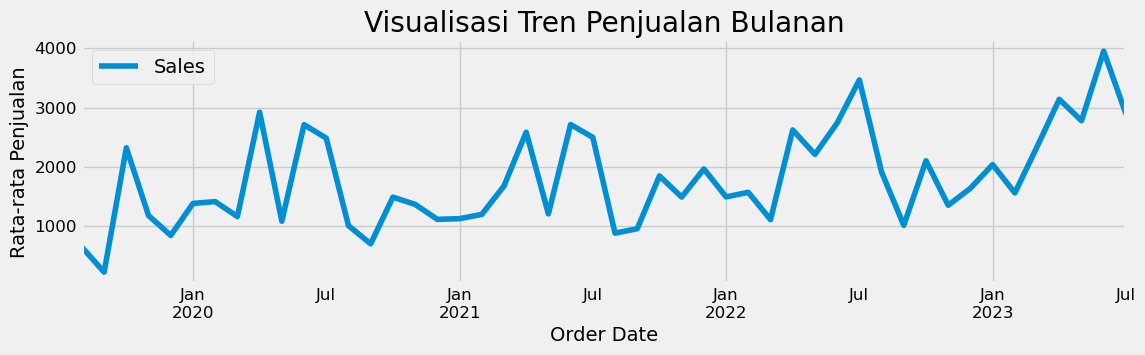

In [ ]:
# Menggabungkan semua transaksi penjualan berdasarkan tanggal yang sama
df = df.groupby('Order Date')['Sales'].sum().reset_index()

# Menetapkan tanggal sebagai indeks tabel untuk mempermudah pengolahan waktu
df = df.set_index('Order Date')

# Mengubah data harian menjadi data bulanan (resampling) dan menghitung rata-ratanya
# Langkah ini membantu menstabilkan fluktuasi data agar tren lebih mudah terbaca
y = df['Sales'].resample('MS').mean()
y = y.reset_index()

# Memastikan kolom 'Order Date' sudah berada dalam format tanggal (datetime) yang benar
y['Order Date'] = pd.to_datetime(y['Order Date'])

# Melakukan penyesuaian waktu (offset) sebanyak 67 bulan ke depan
# Ini biasanya dilakukan untuk menyelaraskan data historis dengan periode waktu analisis saat ini
y['Order Date'] = [i + pd.DateOffset(months=67) for i in y['Order Date']]

# Menetapkan kembali 'Order Date' yang sudah diperbarui sebagai indeks utama
y = y.set_index(['Order Date'])

# Mengidentifikasi tanggal terbaru (paling akhir) dalam dataset kita
maximim_date = y.reset_index()['Order Date'].max()

# --- Visualisasi Tren Penjualan ---
# Menampilkan grafik garis untuk melihat pola naik-turunnya penjualan dari waktu ke waktu
y.plot(figsize=(12, 3))
plt.title("Visualisasi Tren Penjualan Bulanan")
plt.ylabel("Rata-rata Penjualan")
plt.show()

### Interpretasi Tren Penjualan

Grafik deret waktu di atas menunjukkan pergerakan **total penjualan bulanan** yang sangat informatif. Berdasarkan observasi visual, terdapat beberapa poin kunci yang menjadi dasar pemodelan kita:

* **Tren Pertumbuhan:** Terlihat adanya kecenderungan penjualan yang meningkat secara bertahap dalam jangka panjang.
* **Pola Musiman (Seasonality):** Grafik mengindikasikan adanya pola berulang, di mana penjualan melonjak pada periode tertentu setiap tahunnya dan menurun pada periode lainnya.
* **Fluktuasi Teratur:** Meskipun terdapat fluktuasi bulanan, pergerakannya terlihat mengikuti pola tertentu dan bukan sekadar gangguan acak (*noise*).

Temuan ini mengonfirmasi bahwa dataset kita memiliki **struktur tren dan musiman** yang kuat. Oleh karena itu, penggunaan model **SARIMAX** sangat relevan pada tahap selanjutnya, karena model ini dirancang khusus untuk menangkap unsur musiman secara eksplisit guna menghasilkan prediksi yang lebih akurat.

### Analisis Statistik dan Dekomposisi Data

Dalam analisis deret waktu (*time series*), data penjualan tidak hanya dipandang sebagai deretan angka, melainkan hasil interaksi dari empat komponen utama:

* **Level:** Nilai dasar atau rata-rata penjualan pada periode tertentu.
* **Trend:** Arah pergerakan jangka panjang, apakah bisnis sedang tumbuh (naik) atau menurun.
* **Seasonality (Musiman):** Pola berulang yang terjadi pada interval waktu tertentu (misalnya, lonjakan penjualan setiap akhir tahun).
* **Noise/Residual (Residu):** Fluktuasi acak atau "gangguan" yang tidak mengikuti pola tertentu.

Untuk memahami struktur dasar data Superstore, kita melakukan **Dekomposisi Deret Waktu** menggunakan metode *additive decomposition*. Proses ini secara otomatis memisahkan data aktual ke dalam komponen tren, musiman, dan residu. 

Visualisasi dari hasil dekomposisi ini sangat krusial; ia membantu kita memastikan bahwa pola musiman yang kita asumsikan memang benar-benar ada secara konsisten. Pemahaman ini menjadi fondasi utama dalam menentukan parameter model **SARIMAX**, sehingga model tersebut nantinya mampu menangkap pola sistematis bisnis sekaligus tetap tangguh terhadap variasi acak dalam data.


StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 11, Finished, Available, Finished, False)

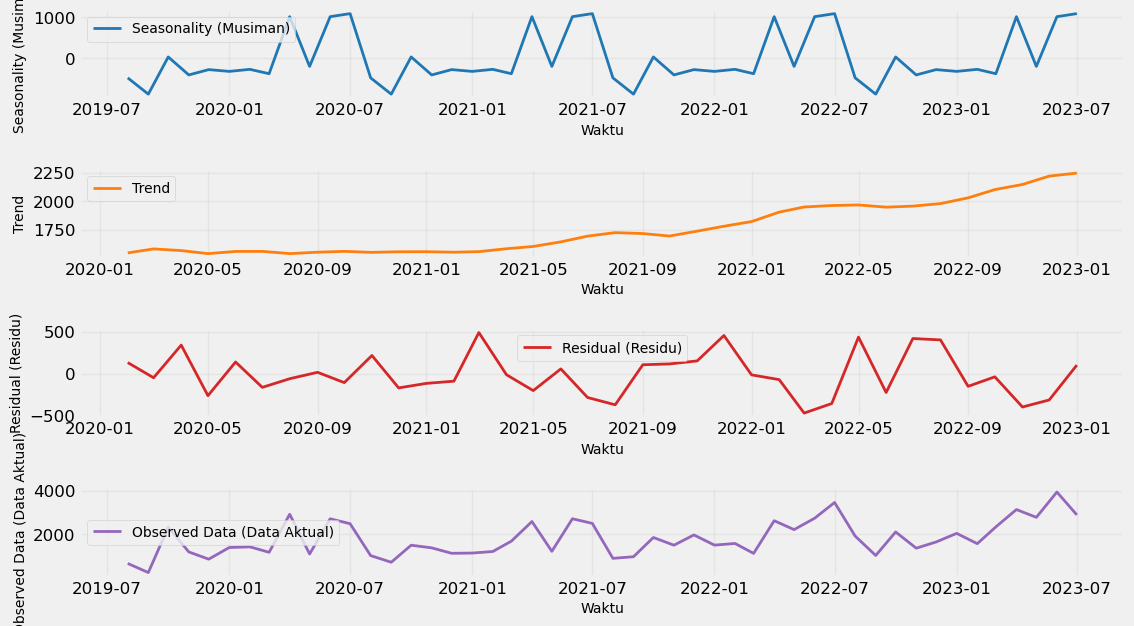

In [ ]:
# Memisahkan data penjualan ke dalam komponen tren, musiman, dan residu
# Kita menggunakan model 'additive' karena variasi musiman terlihat cukup stabil
result = sm.tsa.seasonal_decompose(y, model='additive')

# Menyiapkan daftar komponen untuk divisualisasikan secara terpisah
components = [
    ('Seasonality (Musiman)', result.seasonal),
    ('Trend', result.trend),
    ('Residual (Residu)', result.resid),
    ('Observed Data (Data Aktual)', y)
]

# Menentukan skema warna agar setiap grafik mudah dibedakan secara visual
colors = {
    'Seasonality (Musiman)': 'tab:blue',
    'Trend': 'tab:orange',
    'Residual (Residu)': 'tab:red',
    'Observed Data (Data Aktual)': 'tab:purple'
}

# Mengatur tata letak (layout) grafik dengan 4 baris subplot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 7))
plt.subplots_adjust(hspace=0.8) # Memberi jarak antar grafik agar label tidak tumpang tindih
axes = axes.ravel()

# Melakukan plotting untuk setiap komponen secara otomatis
for ax, (label, data) in zip(axes, components):
    ax.plot(
        data, 
        label=label, 
        color=colors[label], 
        linewidth=2
    )
    ax.set_xlabel('Waktu', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3) # Menambahkan garis bantu (grid) yang tipis agar grafik lebih mudah dibaca

plt.show()

### Interpretasi Hasil Dekomposisi

Hasil dekomposisi mengonfirmasi bahwa data penjualan Superstore memiliki **struktur deret waktu yang sangat jelas**. Berikut adalah poin-poin penting dari setiap komponen:

* **Pola Musiman (Seasonality):**
  Ditemukan pola yang **konsisten dan berulang secara periodik setiap tahun**. Hal ini membuktikan bahwa penjualan sangat dipengaruhi oleh siklus tahunan yang sistematis, sehingga model *forecasting* dapat mempelajari pola ini untuk memprediksi lonjakan di masa depan.

* **Tren Pertumbuhan (Trend):**
  Grafik tren menunjukkan **kecenderungan meningkat secara progresif** dalam jangka panjang. Ini merepresentasikan pertumbuhan bisnis yang stabil dan menjadi indikator bahwa model harus mampu menangkap kenaikan level penjualan dari waktu ke waktu.

* **Sisa Fluktuasi (Residual):**
  Komponen residu bergerak secara acak di sekitar angka nol. Hal ini merupakan sinyal positif yang menunjukkan bahwa sebagian besar informasi penting dalam data sudah berhasil ditangkap oleh komponen tren dan musiman.

* **Kombinasi Data (Observed):**
  Sebagai gabungan dari tren, musiman, dan residu, data aktual memperlihatkan gambaran utuh performa penjualan. Struktur ini memperkuat keputusan kita untuk menggunakan pendekatan **time series forecasting** yang mampu menangani komponen tren dan musiman secara sekaligus.


## Langkah 3: Pelatihan dan Pelacakan Model


Setelah data siap, langkah krusial berikutnya adalah menentukan metode peramalan. Dalam proyek ini, kita menggunakan **Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors (SARIMAX)**. 

### Mengapa Memilih SARIMAX?

SARIMAX dipilih karena kemampuannya dalam menangkap unsur **tren** dan **musiman** secara eksplisit, yang merupakan karakteristik utama dari data penjualan kita. Beberapa pertimbangan utamanya meliputi:

* **Model Baseline yang Solid:** Sebagai model statistik klasik, SARIMAX memberikan titik awal yang stabil dan teruji.
* **Interpretabilitas Tinggi:** Kita dapat menjelaskan komponen tren dan musiman secara transparan kepada pemangku kepentingan non-teknis.
* **Efisien & Ringan:** Tidak membutuhkan daya komputasi besar dan sangat mudah diintegrasikan dengan alur kerja **Microsoft Fabric** serta **MLflow**.

### Perbandingan dengan Pendekatan Lain

Untuk memberikan gambaran posisi SARIMAX, berikut adalah perbandingan singkat dengan beberapa metode populer lainnya:

| Metode | Karakteristik | Alasan Tidak Dipilih (Untuk Demo Ini) |
| :--- | :--- | :--- |
| **Holt-Winters** | Sederhana & interpretabel. | Terbatas karena tidak mendukung variabel eksternal. |
| **Prophet** | Bagus untuk hari libur & tren otomatis. | Kontrol statistik lebih terbatas dibanding SARIMAX. |
| **Machine Learning** | Jago menangkap pola non-linear. | Membutuhkan *feature engineering* yang rumit. |
| **Deep Learning** | Sangat kuat untuk data besar (LSTM/GRU). | Terlalu kompleks dan sulit diinterpretasikan (*black box*). |

### Ekosistem Pelacakan Eksperimen

Proses pengembangan model ini didukung oleh infrastruktur modern di **Microsoft Fabric**:

1.  **MLflow & Fabric Autologging:** Secara otomatis mencatat parameter dan metrik setiap percobaan. Hal ini memastikan setiap iterasi model dapat ditelusuri kembali (*reproducible*) dengan mudah.
2.  **Lakehouse (Format Delta):** Menjadi sumber data terpusat yang menjamin konsistensi data mulai dari tahap pelatihan hingga visualisasi akhir di Power BI.


### Hyperparameter Tuning & Seleksi Metrik

Model **SARIMAX** dikonfigurasikan menggunakan dua kelompok parameter utama: **Order** `(p, d, q)` untuk komponen tren dan **Seasonal Order** `(P, D, Q, s)` untuk pola musiman. Pada tahap ini, kita melakukan evaluasi sistematis untuk memperoleh **konfigurasi baseline** yang optimal melalui pendekatan *Grid Search*.

#### Definisi Parameter SARIMAX
Untuk memahami hasil eksperimen, penting untuk mengetahui peran masing-masing parameter dalam menangkap pola data:

**Komponen Tren (Non-Musiman):**
* **`p` (Autoregression):** Jumlah observasi masa lalu yang digunakan untuk memprediksi nilai saat ini. Menunjukkan seberapa kuat hubungan nilai hari ini dengan hari-hari sebelumnya.
* **`d` (Differencing):** Jumlah proses pengurangan nilai sekarang dengan nilai sebelumnya untuk menghilangkan **tren** agar data menjadi stabil (stasioner).
* **`q` (Moving Average):** Jumlah sisa kesalahan (*error*) dari prediksi masa lalu yang digunakan untuk memperbaiki prediksi saat ini.

**Komponen Musiman (Seasonal):**
* **`P` (Seasonal Autoregression):** Mirip dengan `p`, namun menggunakan observasi dari siklus musiman sebelumnya (misal: Januari tahun lalu untuk prediksi Januari tahun ini).
* **`D` (Seasonal Differencing):** Proses *differencing* pada tingkat musiman untuk menghilangkan pola musiman yang berulang setiap tahun.
* **`Q` (Seasonal Moving Average):** Menggunakan *error* dari siklus musiman masa lalu untuk memperbaiki akurasi model.
* **`s` (Seasonality):** Panjang satu siklus musiman. Untuk data bulanan dengan pola tahunan, nilainya adalah **12**.

#### Strategi Grid Search
Penyetelan dilakukan dengan menguji kombinasi parameter dalam rentang terbatas guna menjaga efisiensi komputasi:
* **Rentang Parameter:** Nilai `p`, `d`, dan `q` diuji dalam rentang **0 hingga 1**.
* **Periode Musiman:** Ditetapkan sebesar **12 bulan**, sesuai dengan karakteristik data penjualan bulanan.

#### Perbandingan dan Definisi Metrik Evaluasi
Kita menggunakan **AIC** untuk memilih model terbaik dan **MAPE** untuk mengomunikasikan akurasi kepada tim bisnis. Berikut adalah perbandingannya dengan metrik lain:

| Fokus Evaluasi | Metrik | Definisi Singkat | Alasan Tidak Dipilih Sebagai Metrik Utama |
| :--- | :--- | :--- | :--- |
| **Struktur Model** | **AIC** | Ukuran keseimbangan antara kecocokan data (*fit*) dan kesederhanaan model. | **Dipilih** karena paling cerdas dalam mencegah model yang terlalu rumit (*overfitting*). |
| | **BIC** | Mirip AIC, namun memberikan penalti yang lebih berat untuk setiap parameter baru. | Terlalu kaku; sering kali justru menghilangkan pola musiman penting yang dibutuhkan. |
| **Akurasi Prediksi** | **MAPE** | Rata-rata persentase absolut kesalahan prediksi dibandingkan data aktual. | **Dipilih** karena hasilnya universal dan mudah dipahami bisnis (misal: "Akurasi 95%"). |
| | **MAE** | Rata-rata selisih absolut antara prediksi dan aktual dalam unit asli (misal: Rupiah). | Sulit dibandingkan jika kita menganalisis produk dengan skala harga yang berbeda jauh. |
| | **RMSE** | Akar kuadrat dari rata-rata selisih kuadrat antara prediksi dan aktual. | Terlalu sensitif terhadap lonjakan data ekstrem (*outlier*), memberikan gambaran yang bias. |
| | **R-Squared** | Statistik yang menunjukkan seberapa besar variasi data dapat dijelaskan model. | Sering memberikan nilai tinggi "palsu" pada data *time series* karena faktor tren alami. |

#### Eksekusi dan Pelacakan
Seluruh kombinasi parameter dilatih secara otomatis menggunakan **Grid Search**, dan hasilnya diurutkan berdasarkan nilai AIC terendah. Proses eksperimen ini direkam sepenuhnya menggunakan **MLflow** dan **Fabric Autologging**, memastikan transparansi dan kemudahan reproduksi di dalam ekosistem Microsoft Fabric.


In [ ]:
# Menentukan rentang parameter tren (p, d, q) antara 0 dan 1
p = d = q = range(0, 2)

# Menghasilkan semua kombinasi unik untuk parameter non-musiman
pdq = list(itertools.product(p, d, q))

# Menghasilkan kombinasi parameter musiman (P, D, Q) dengan siklus tahunan (s=12)
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

results_list = []

# Melakukan iterasi untuk mencari kombinasi parameter yang menghasilkan model terbaik
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            # Membangun model SARIMAX untuk setiap kombinasi
            mod = sm.tsa.statespace.SARIMAX(
                y,
                order=param,
                seasonal_order=param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = mod.fit(disp=False)
            
            # Menyimpan hasil perhitungan AIC untuk dievaluasi
            results_list.append({
                "order": param,
                "seasonal_order": param_seasonal,
                "AIC": res.aic
            })
        except Exception:
            # Mengabaikan kombinasi parameter yang tidak stabil secara matematis
            continue

# Merangkum hasil eksperimen ke dalam DataFrame
aic_df = pd.DataFrame(results_list)

# Mengurutkan model dari nilai AIC terkecil (semakin kecil, semakin optimal)
aic_df = aic_df.sort_values(by="AIC", ascending=True).reset_index(drop=True)

# Menampilkan 5 kandidat model terbaik sebagai baseline
display(aic_df.head())

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 12, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, ad122cc9-66a1-4712-bf9f-7fe1ec24c390)

### Hasil Hyperparameter Tuning dan Pemilihan Model

Berdasarkan evaluasi sistematis pada tahap *Grid Search*, kita telah mendapatkan konfigurasi **parameter order** dan **seasonal order** yang menghasilkan nilai **Akaike Information Criterion (AIC) terendah**:

* **Order (p, d, q):** `(0, 1, 1)`
* **Seasonal Order (P, D, Q, s):** `(0, 1, 1, 12)`
* **AIC:** ± **325.30**

Konfigurasi ini dipilih karena mencapai keseimbangan optimal antara **kualitas kecocokan model (*goodness of fit*)** dan **kesederhanaan model**. Dengan nilai AIC terendah, model ini memiliki risiko *overfitting* yang paling kecil namun tetap mampu menangkap esensi data secara akurat.

### Interpretasi Parameter Model Terpilih

Berikut adalah bedah makna dari setiap parameter terpilih dan bagaimana ia mencerminkan karakteristik data penjualan kita:

#### Komponen Tren (Non-Musiman)
* **`p = 0` (Autoregressive):** Model tidak bergantung langsung pada nilai penjualan di bulan sebelumnya secara mentah. Prediksi lebih banyak dipengaruhi oleh rata-rata pergerakan error.
* **`d = 1` (Differencing):** Mengonfirmasi adanya **tren** dalam data. Kita perlu melakukan satu kali pengurangan (selisih) antar periode agar data menjadi stasioner (stabil).
* **`q = 1` (Moving Average):** Model memperhitungkan satu "kejutan" atau error dari periode lalu untuk mengoreksi prediksi saat ini.



#### Komponen Musiman (Seasonal)
* **`P = 0` (Seasonal AR):** Tidak ada pengaruh langsung dari nilai musiman tahun lalu terhadap nilai saat ini di luar pola differencing.
* **`D = 1` (Seasonal Differencing):** Menegaskan adanya **pola musiman tahunan yang kuat**. Perlu dilakukan selisih antar tahun (Januari tahun ini vs Januari tahun lalu) untuk menstabilkan pola berulang tersebut.
* **`Q = 1` (Seasonal MA):** Model menggunakan error musiman dari siklus tahun lalu untuk menyempurnakan prediksi.
* **`s = 12` (Seasonal Period):** Mengunci siklus pengulangan pada angka 12 bulan (tahunan).

### Konfigurasi Teknis Tambahan
* **`enforce_stationarity = False`** Pengaturan ini memberikan keleluasaan bagi model untuk tetap "belajar" meskipun data belum sepenuhnya stabil (stasioner) di awal proses. Hal ini sangat penting untuk mencegah model berhenti bekerja secara tiba-tiba (*gagal konvergensi*) akibat aturan matematis yang terlalu kaku.

* **`enforce_invertibility = False`** Parameter ini berfungsi sebagai "pengaman" agar proses pencarian solusi terbaik (optimasi) tetap berjalan lancar. Dengan mematikan fungsi ini, kita meminimalkan risiko error teknis saat model menemui angka-angka matematis yang sulit diolah, sehingga hasil prediksi tetap bisa dihasilkan tanpa hambatan.

### Kesimpulan Baseline
Secara keseluruhan, model SARIMAX `(0, 1, 1)x(0, 1, 1, 12)` ini menunjukkan bahwa data kita didominasi oleh **tren pertumbuhan** dan **siklus tahunan**. Model ini cukup ramping untuk menghindari kompleksitas yang tidak perlu, namun sangat representatif untuk digunakan sebagai fondasi *forecasting* kita.


### Pelatihan Model Final (Train Model)

Setelah mendapatkan kombinasi parameter terbaik dari tahap *tuning*, langkah selanjutnya adalah melatih model **SARIMAX** final menggunakan konfigurasi `order = (0, 1, 1)` dan `seasonal_order = (0, 1, 1, 12)`. Model dilatih menggunakan data penjualan bulanan yang telah diagregasi, sehingga mampu menangkap pola jangka panjang secara akurat.

#### Konfigurasi Teknis Tambahan
Untuk memastikan proses pelatihan berjalan stabil, kita menerapkan dua pengaturan berikut:
* **`enforce_stationarity = False`:** Memberikan keleluasaan bagi model untuk belajar tanpa harus memaksakan aturan stasioneritas yang kaku, guna mencegah kegagalan proses di tengah jalan.
* **`enforce_invertibility = False`:** Berfungsi sebagai "pengaman" agar proses pencarian solusi terbaik (optimasi) tetap lancar meskipun menemui angka matematis yang kompleks.

#### Evaluasi Hasil Estimasi
Setelah pelatihan selesai, kita meninjau ringkasan hasil melalui `results.summary()`. Dokumen ini memberikan wawasan mendalam mengenai:
* **Estimasi Parameter:** Seberapa besar pengaruh komponen tren dan musiman terhadap model.
* **Signifikansi Statistik:** Memastikan bahwa parameter yang terpilih memang benar-benar berpengaruh (valid secara statistik).
* **Metrik Kecocokan (AIC/BIC):** Memverifikasi kembali bahwa model ini merupakan yang paling efisien.
* **Diagnostik Residual:** Memastikan tidak ada pola informasi yang tertinggal dalam sisa kesalahan (*error*).


In [ ]:
# Membangun model SARIMAX menggunakan parameter terbaik hasil Tuning
# Order (0, 1, 1) menangkap tren, Seasonal Order (0, 1, 1, 12) menangkap pola tahunan
mod = sm.tsa.statespace.SARIMAX(
    y,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Melatih model menggunakan data penjualan historis
# 'disp=False' digunakan agar output proses iterasi yang panjang tidak memenuhi layar
results = mod.fit(disp=False)

# Menampilkan ringkasan (summary) hasil estimasi parameter model
# Bagian ini sangat krusial untuk memverifikasi validitas statistik model kita
print(results.summary())

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 13, Finished, Available, Finished, False)

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -159.651
Date:                            Wed, 26 Aug 2026   AIC                            325.303
Time:                                    08:08:51   BIC                            328.436
Sample:                                08-01-2019   HQIC                           325.983
                                     - 07-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8642      0.174     -4.981      0.000      -1.204      -0.524
ma.S.L12      -1.0439      5.360   

### Interpretasi Hasil Pelatihan Model SARIMAX

Ringkasan hasil estimasi memberikan gambaran mendalam mengenai performa dan karakteristik model **SARIMAX(0, 1, 1) × (0, 1, 1, 12)** yang telah dilatih.

#### 1. Informasi Umum Model
* **Dataset:** Model menggunakan 48 observasi bulanan (Agustus 2019 – Juli 2023).
* **Konfigurasi:** Model secara efektif menangkap tren melalui *differencing* non-musiman (`d=1`) dan pola tahunan melalui *differencing* musiman (`D=1`).
* **Kualitas (AIC = 325.303):** Nilai ini mengonfirmasi bahwa model berada pada titik keseimbangan optimal antara akurasi dan efisiensi struktur.



#### 2. Bedah Parameter Model
* **`ma.L1` (Moving Average):** Memiliki *p-value* **0.000 (Signifikan)**. Artinya, fluktuasi jangka pendek sangat memengaruhi prediksi, dan model berhasil menangkap ketergantungan ini dengan sangat baik.
* **`ma.S.L12` (Seasonal MA):** Memiliki *p-value* **0.846 (Tidak Signifikan)**. Hal ini menunjukkan pengaruh error musiman tidak terlalu kuat, yang sering terjadi pada data dengan durasi terbatas. Namun, parameter ini tetap dipertahankan untuk menjaga struktur musiman yang utuh.
* **`sigma2`:** Menunjukkan stabilitas varians dalam model, memastikan tidak ada lonjakan kesalahan yang ekstrem.

#### 3. Diagnostik Residual (Uji Validitas)
Langkah ini krusial untuk memastikan model "sehat" secara statistik:
* **Uji Ljung-Box (p-value = 0.74):** Residual bersifat acak (tidak ada informasi yang tertinggal).
* **Uji Jarque-Bera (p-value = 0.45):** Kesalahan prediksi berdistribusi normal.
* **Uji Heteroskedastisitas (p-value = 0.85):** Varians kesalahan stabil dari waktu ke waktu.

### Kesimpulan & Langkah Selanjutnya
Model ini dinyatakan **layak dan stabil** sebagai *baseline forecasting*. Meskipun ada parameter musiman yang kurang signifikan, secara keseluruhan model memenuhi asumsi utama deret waktu dan siap memproyeksikan nilai penjualan.

Selanjutnya, model akan melakukan **One-Step-Ahead Forecast** untuk periode **12 bulan ke depan**. Prediksi ini akan memanfaatkan informasi aktual hingga periode terakhir untuk memberikan estimasi penjualan yang lebih presisi dan dapat diandalkan bagi tim bisnis.


StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 14, Finished, Available, Finished, False)

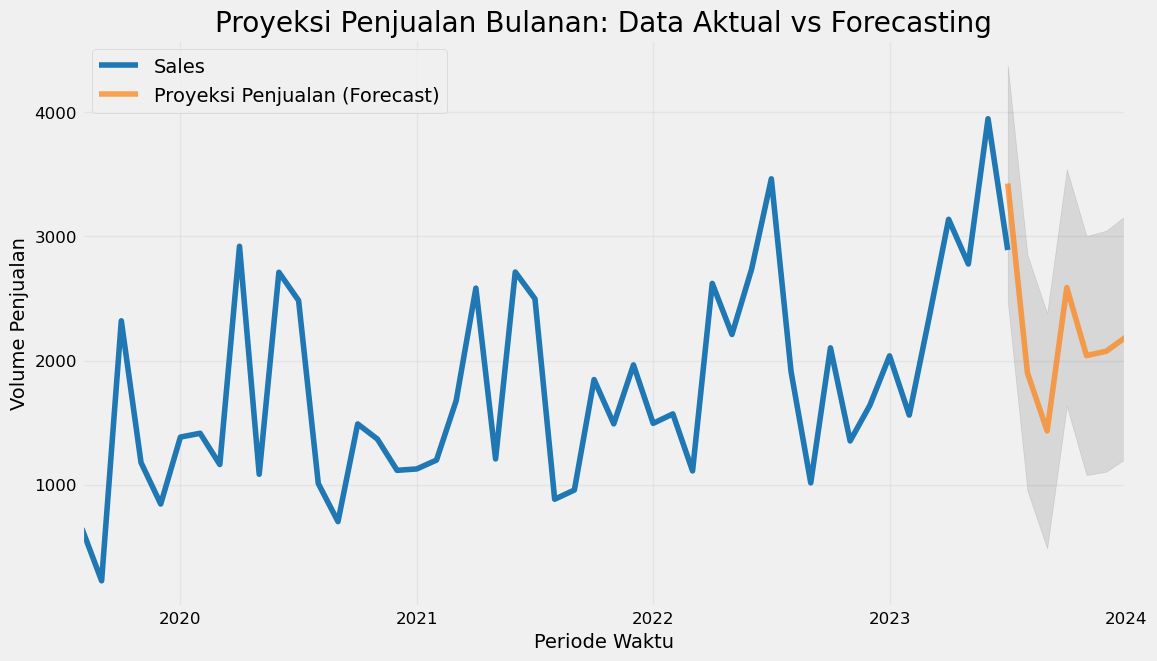

In [ ]:
# Melakukan prediksi mulai dari tanggal terakhir di dataset hingga 12 bulan ke depan
# 'dynamic=False' berarti model menggunakan informasi aktual terbaru untuk setiap langkah prediksi
pred = results.get_prediction(
    start=maximim_date, 
    end=maximim_date + pd.DateOffset(months=6), 
    dynamic=False
)

# Mengambil 'Confidence Interval' (rentang ketidakpastian) dari hasil prediksi
pred_ci = pred.conf_int()

# Membuat plot untuk membandingkan data historis dengan hasil ramalan
ax = y['2019':].plot(label='Data Aktual (Historis)', color='#1f77b4')
pred.predicted_mean.plot(
    ax=ax, 
    label='Proyeksi Penjualan (Forecast)', 
    color='#ff7f0e',
    alpha=.7, 
    figsize=(12, 7)
)

# Menambahkan area arsir untuk menunjukkan batas atas dan bawah prediksi (uncertainty)
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1], 
    color='k', 
    alpha=.1
)

# Pengaturan label grafik agar informatif bagi pengguna
ax.set_xlabel('Periode Waktu')
ax.set_ylabel('Volume Penjualan')
plt.title('Proyeksi Penjualan Bulanan: Data Aktual vs Forecasting')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

### Analisis Hasil Forecasting & Tata Kelola Model

Visualisasi akhir memberikan gambaran transparan mengenai kemampuan model dalam memproyeksikan data. Berikut adalah analisis mendalam terhadap hasil tersebut serta langkah integrasi sistem yang dilakukan.

#### Interpretasi Grafik Forecasting
Grafik memperlihatkan perbandingan antara data penjualan historis dan hasil proyeksi model **SARIMAX**. Poin-poin penting yang teramati meliputi:

* **Kesesuaian Tren & Musiman:** Garis *forecasting* mengikuti arah umum data historis. Ini membuktikan bahwa model berhasil menyerap struktur utama deret waktu tanpa menyimpang secara ekstrem (*overfitting*).
* **Stabilitas One-Step-Ahead:** Dengan memanfaatkan informasi aktual hingga periode sebelumnya (`dynamic=False`), estimasi tetap stabil dan realistis untuk evaluasi jangka pendek.
* **Dinamika Ketidakpastian:** Area abu-abu (**Interval Kepercayaan**) yang melebar seiring bertambahnya waktu mencerminkan risiko yang meningkat secara alami saat kita memprediksi masa depan yang lebih jauh.

#### Strategi Validasi vs. Proyeksi Masa Depan
* **`predictions` (Validasi Performa):** Menghasilkan prediksi pada periode 12 bulan terakhir dari data historis. Tujuannya adalah membandingkan hasil model dengan data aktual untuk evaluasi kuantitatif menggunakan metrik seperti **MAPE**.
* **`predictions_future` (Proyeksi Bisnis):** Menghasilkan prediksi untuk 12 bulan ke depan setelah observasi terakhir. Hasil ini berfungsi sebagai proyeksi murni untuk kebutuhan perencanaan bisnis.


#### Manajemen Eksperimen dengan MLflow
Agar hasil ini dapat digunakan kembali secara terstruktur, model dikelola menggunakan ekosistem **MLflow** di dalam Microsoft Fabric:

* **Pencatatan Artefak:** Model disimpan secara utuh menggunakan `mlflow.statsmodels.log_model`.
* **Pelacakan Parameter:** Konfigurasi utama seperti *order*, *seasonal order*, dan pengaturan stasioneritas dicatat sebagai metadata eksperimen.
* **Sistem Registry:** Model didaftarkan dengan nama yang konsisten agar mudah diidentifikasi dan dimuat kembali (`load_model`) tanpa perlu proses pelatihan ulang.


In [ ]:
# Memvalidasi hasil forecasting
predictions = results.get_prediction(
    start=maximim_date - pd.DateOffset(months=VALIDATION_MONTHS - 1),
    end=maximim_date,
    dynamic=False
)

# Melakukan forecasting untuk data masa depan yang belum terlihat
predictions_future = results.get_prediction(
    start=maximim_date + pd.DateOffset(months=1),
    end=maximim_date + pd.DateOffset(months=FORECAST_MONTHS),
    dynamic=False
)

# Mencatat (log) model dan parameter ke MLflow
model_name = f"{EXPERIMENT_NAME}-Sarimax"

with mlflow.start_run(run_name="Sarimax") as run:
    mlflow.statsmodels.log_model(
        results,
        model_name,
        registered_model_name=model_name
    )
    mlflow.log_params({
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12),
        "enforce_stationarity": False,
        "enforce_invertibility": False
    })
    model_uri = f"runs:/{run.info.run_id}/{model_name}"
    print("Model disimpan pada run %s" % run.info.run_id)
    print(f"Model URI: {model_uri}")

mlflow.end_run()

# Memuat model yang telah disimpan
loaded_model = mlflow.statsmodels.load_model(model_uri)


StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 15, Finished, Available, Finished, False)

Model disimpan pada run 0f3e6e66-14ef-450d-9c5c-13705dab04da
Model URI: runs:/0f3e6e66-14ef-450d-9c5c-13705dab04da/aisample-superstore-forecast-2-Sarimax


## Langkah 4: Melakukan Skoring Model dan Menyimpan Prediksi

Pada tahap ini, hasil forecasting disusun agar dapat digunakan langsung dalam **Power BI**. Data forecasting masa depan disiapkan dengan mengisi nilai **`Forecasted_Sales`** dan membiarkan **`Actual_Sales`** kosong, sementara data historis menyertakan baik nilai aktual maupun hasil forecasting untuk keperluan evaluasi.

Untuk mengukur akurasi model pada periode historis, dihitung **Mean Absolute Percentage Error (MAPE)** antara nilai aktual dan nilai hasil forecasting. Metrik ini hanya diterapkan pada data yang memiliki nilai aktual.

Seluruh data kemudian digabungkan ke dalam satu struktur yang konsisten dan disimpan sebagai tabel **Delta** di lakehouse. Dengan pendekatan ini, Power BI dapat mengakses data aktual, hasil forecasting, dan metrik evaluasi dari satu sumber terpusat untuk keperluan visualisasi dan analisis lanjutan.

In [ ]:
# Menghasilkan prediksi pada periode historis untuk validasi akurasi
predictions = results.get_prediction(
    start=maximim_date - pd.DateOffset(months=VALIDATION_MONTHS - 1),
    end=maximim_date,
    dynamic=False
)

# Menghasilkan proyeksi murni untuk periode masa depan yang belum terjadi
predictions_future = results.get_prediction(
    start=maximim_date + pd.DateOffset(months=1),
    end=maximim_date + pd.DateOffset(months=FORECAST_MONTHS),
    dynamic=False
)

# Proses logging model ke dalam ekosistem MLflow
model_name = f"{EXPERIMENT_NAME}-Sarimax"

with mlflow.start_run(run_name="Sarimax") as run:
    # Menyimpan artefak model statsmodels secara utuh
    mlflow.statsmodels.log_model(
        results,
        model_name,
        registered_model_name=model_name
    )
    
    # Mencatat metadata parameter agar eksperimen dapat direproduksi
    mlflow.log_params({
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12),
        "enforce_stationarity": False,
        "enforce_invertibility": False
    })
    
    model_uri = f"runs:/{run.info.run_id}/{model_name}"
    print(f"Model berhasil diamankan pada Run ID: {run.info.run_id}")
    print(f"Alamat Model (URI): {model_uri}")

mlflow.end_run()

# Memuat kembali model dari Registry untuk memastikan siap digunakan (Inference)
loaded_model = mlflow.statsmodels.load_model(model_uri)

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 16, Finished, Available, Finished, False)

Model berhasil diamankan pada Run ID: 828982a2-05e8-42e5-b372-dc82f0d77525
Alamat Model (URI): runs:/828982a2-05e8-42e5-b372-dc82f0d77525/aisample-superstore-forecast-2-Sarimax


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# Actual validation data
y_true = y.loc[predictions.predicted_mean.index]

# Prediksi validation
y_pred = predictions.predicted_mean

# Hitung MAPE (%)
mape = mean_absolute_percentage_error(
    y_true.squeeze(),
    y_pred
) * 100

print(f"MAPE: {mape:.2f}%")

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 17, Finished, Available, Finished, False)

MAPE: 17.47%


In [ ]:
# Data aktual
actual_df = y.reset_index()
actual_df.columns = ['periode', 'sales']
actual_df['forecast_sales'] = np.nan
actual_df['lower_ci'] = np.nan
actual_df['upper_ci'] = np.nan
actual_df['mape'] = mape
actual_df['type'] = 'actual'

# Data forecast
forecast_df = pd.DataFrame({
    'periode': pred.predicted_mean.index,
    'sales': np.nan,
    'forecast_sales': pred.predicted_mean.values,
    'lower_ci': pred_ci.iloc[:, 0].values,
    'upper_ci': pred_ci.iloc[:, 1].values,
    'mape': mape,
    'type': 'forecast'
})

# Gabungkan
combined_df = pd.concat(
    [actual_df, forecast_df],
    ignore_index=True
).sort_values('periode')

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 18, Finished, Available, Finished, False)

In [ ]:
spark_combined_df = spark.createDataFrame(combined_df)

spark_combined_df.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("sales_actual_forecast")

StatementMeta(, 7b804658-1895-4619-b23b-7d60e808cbe3, 19, Finished, Available, Finished, False)

## Langkah 5: Business Intelligence melalui Visualisasi di Power BI


Link: https://app.fabric.microsoft.com/reportEmbed?reportId=7547531f-a3f7-4d2e-b887-f0f1c48f4789&autoAuth=true&ctid=fa53a526-b95e-432f-b6f5-45b7048bc217

Tahap evaluasi akhir dilakukan melalui integrasi hasil model ke dalam dashboard **Power BI**.  
Tujuan utama tahap ini adalah **memvalidasi performa model secara kuantitatif dan visual** sebelum hasil peramalan digunakan sebagai dasar pengambilan keputusan strategis.

### Interpretasi Metrik MAPE (17,47%)

Berdasarkan hasil evaluasi sistem, model menghasilkan nilai **Mean Absolute Percentage Error (MAPE)** sebesar **17,47%**.

- **Definisi**  
  MAPE mengukur rata-rata selisih antara nilai hasil peramalan dan nilai aktual dalam bentuk persentase.

- **Makna Angka**  
  Nilai **17,47%** menunjukkan bahwa secara rata-rata prediksi model menyimpang sekitar **17,47%** dari penjualan riil, baik dalam bentuk *overestimate* maupun *underestimate*.

- **Relevansi Bisnis**  
  Untuk data penjualan yang memiliki **fluktuasi tren dan pola musiman**, nilai ini tergolong **cukup solid dan layak digunakan** sebagai dasar perencanaan operasional dan strategis (threshold MAPE antara 10-20%).

### Analisis Perbandingan Visual (Actual vs Forecast)

Visualisasi utama pada dashboard menampilkan perbandingan antara data aktual dan hasil peramalan:

- **Garis Biru Muda — Penjualan Aktual**  
  Merepresentasikan performa penjualan riil perusahaan berdasarkan data historis.

- **Garis Biru Tua — Hasil Forecasting (SARIMAX)**  
  Menunjukkan nilai proyeksi yang dihasilkan oleh model time series.

**Observasi Utama:**  
Model mampu mengikuti pola penjualan dengan baik, khususnya pada periode **enam bulan pertama tahun 2023**, di mana kedua garis terlihat selaras. Hal ini mengindikasikan bahwa model berhasil menangkap:
- arah **tren jangka menengah**, dan
- **pola musiman** yang konsisten dalam data penjualan.

### Implikasi terhadap Pengambilan Keputusan Strategis

Dengan tingkat akurasi yang telah tervalidasi, model ini memberikan **tingkat kepercayaan yang memadai** untuk meramalkan penjualan pada periode **12 bulan terakhir.**

Hasil proyeksi dapat dimanfaatkan oleh manajemen untuk:

- **Manajemen Persediaan**  
  Mengoptimalkan level stok guna menghindari kelebihan maupun kekurangan barang.

- **Pengadaan (Procurement)**  
  Menyusun jadwal dan volume pembelian yang lebih efisien dan berbasis data.

- **Perencanaan Bisnis**  
  Menetapkan target penjualan serta alokasi sumber daya operasional yang lebih realistis dan terukur.


## Limitasi, Rekomendasi, dan Konklusi

### Limitasi Model
Meskipun model memiliki performa yang baik, terdapat beberapa batasan yang perlu diperhatikan:
* **Asumsi Pola Berulang:** Model mengasumsikan bahwa pola masa lalu akan berulang di masa depan; perubahan pasar yang bersifat anomali mungkin tidak tertangkap sepenuhnya.
* **Data Internal:** Model saat ini hanya menggunakan data penjualan historis tanpa mempertimbangkan faktor eksternal seperti aktivitas kompetitor.
* **Horizon Waktu:** Akurasi prediksi cenderung menurun seiring bertambahnya durasi proyeksi ke masa depan yang sangat jauh.

### Rekomendasi Strategis
Untuk meningkatkan kualitas prediksi di masa depan, disarankan untuk:
* **Integrasi Variabel Eksternal:** Menambahkan data hari libur atau periode promosi sebagai regressor tambahan dalam SARIMAX.
* **Retraining Berkala:** Memanfaatkan pipeline MLflow untuk memperbarui model secara otomatis dengan data terbaru setiap bulannya.
* **Monitoring Akurasi:** Memantau pergerakan MAPE secara rutin di Power BI untuk mendeteksi kapan model perlu disesuaikan kembali (model drift).

### Konklusi
Proyek ini berhasil membuktikan bahwa pendekatan data-driven menggunakan model **SARIMAX** dapat memberikan proyeksi penjualan yang stabil dan dapat dipertanggungjawabkan secara statistik. Dengan nilai **MAPE sebesar 17,47%**, manajemen kini memiliki alat bantu yang andal untuk mengoptimalkan perencanaan stok dan strategi pengadaan bahan baku hingga tahun 2024, guna mendukung efisiensi operasional perusahaan secara keseluruhan.
